# Optimizing the Universe in a Container

This notebook demonstrates a field-level inverse problem with **Tesseract** and **Disco-DJ** (https://github.com/cosmo-sims/DISCO-DJ).
Specifically, it shows how one can reconstruct the **initial conditions** of a **cosmological simulation** that give rise to a given target density field at the present day using gradient-based optimization. The demo target is a noisy cosmological late-time density field with a visible tesseract-shaped structure embedded, stored in `target_bundle.npz`. The optimizer will search for an initial noise field that evolves into a matching late-time density field.
In this demo, we will use resolution $64^3$. A GPU is required for the optimization (a laptop GPU is enough).

The structure of this notebook roughly follows https://docs.pasteurlabs.ai/projects/tesseract-core/latest/content/demo/cfd-optimization.html, but instead of solving the *Navier-Stokes equations*, Disco-DJ provides a Jax-based large-scale structure formation simulator that solves the **Vlasov-Poisson equations** via a cosmological $N$-body simulation to evolve the initial density field from the early universe to the present day.

The reconstruction uses a Gaussian data likelihood, a Gaussian white-noise prior (in Fourier space), a Fourier-space preconditioner (aka Fourier-mode specific learning rates), and a coarse-to-fine k-space annealing schedule. The cutoff starts on large scales and gradually admits smaller-scale structure, so large structures present in the target are optimized first, with smaller scales following later.

### Motivation
In a more realistic setting, one would apply such an approach to data from **galaxy surveys** to reconstruct the over- and underdensities that were seeded in our cosmic neighborhood within a fraction of the universe's first second, potentially together with inference on cosmological parameters such as the expansion rate of the universe, its dark matter and dark energy content, etc.

In [1]:
# Imports
from pathlib import Path
import sys
import os
import gc
import tempfile
# os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

ROOT = Path.cwd()
if not (ROOT / "target_bundle.npz").exists():
    candidate = ROOT / "discodj_tesseract_example" / "embedded_tesseract"
    if candidate.exists():
        ROOT = candidate.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
PROJECT_ROOT = ROOT.parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import jax
import jax.numpy as jnp
import numpy as np
import plotly.graph_objects as go
from IPython.display import display, Image
from matplotlib import pyplot as plt
from PIL import Image as PILImage
from plotly.subplots import make_subplots
from scipy.optimize import minimize
from tesseract_core import Tesseract
from tesseract_jax import apply_tesseract
from tqdm import tqdm


## Step 1: Load the target bundle

The target bundle contains the noisy observation, the clean late-time target, the initial white-noise modes used as the optimizer starting point, and the fixed Fourier grids needed by the likelihood and prior. The first visualizations show the late-time target in 3D and in a representative 2D slice.


In [2]:
os.chdir(ROOT)
TARGET_BUNDLE = ROOT / "target_bundle.npz"
OUTPUTS = ROOT / "outputs"
OUTPUTS.mkdir(exist_ok=True)

with np.load(TARGET_BUNDLE) as target_bundle:
    target_clean = target_bundle["target"].astype(np.float32)
    target_cosmological_base = target_bundle["target_cosmological_base"].astype(np.float32)
    target_observation = target_bundle["target_observation"].astype(np.float32)
    initial_modes = target_bundle["initial_white_noise_fourier"].astype(np.float32)
    k_grid = target_bundle["k_grid"].astype(np.float32)
    linear_power_grid = target_bundle["linear_power_grid"].astype(np.float32)
    rfft_factor = target_bundle["rfft_factor"].astype(np.float32)
    uv_filter = target_bundle["uv_filter"].astype(bool)
    noise_sigma = float(target_bundle["noise_sigma"])
    n2 = float(target_bundle["n2"])
    k_nyquist = float(target_bundle["k_nyquist"])

size = target_observation.shape[0]

target_observation.shape, initial_modes.shape, noise_sigma, k_nyquist

((64, 64, 64), (64, 64, 33, 2), 1.0, 2.0106194019317627)

In [3]:
OFFSET_FOR_LOG_PLOT = 0.1
def log_density_for_plot(delta):
    return np.log10(np.maximum(1.0 + OFFSET_FOR_LOG_PLOT + np.asarray(delta), OFFSET_FOR_LOG_PLOT))

target_view = log_density_for_plot(target_observation)[::2, ::2, ::2]
x, y, z = np.mgrid[:target_view.shape[0], :target_view.shape[1], :target_view.shape[2]]
vmin, vmax = np.percentile(target_view, [65.0, 99.7])

fig = go.Figure(
    data=go.Volume(
        x=x.ravel(),
        y=y.ravel(),
        z=z.ravel(),
        value=target_view.ravel(),
        isomin=vmin,
        isomax=vmax,
        opacity=0.08,
        surface_count=14,
        colorscale="Magma",
        caps=dict(x_show=False, y_show=False, z_show=False),
        colorbar=dict(title="log density"),
    )
)
fig.update_layout(
    title="Noisy target observation",
    width=760,
    height=700,
    margin=dict(l=0, r=0, t=45, b=0),
    scene=dict(aspectmode="cube", xaxis=dict(visible=False), yaxis=dict(visible=False), zaxis=dict(visible=False)),
)
fig.show()

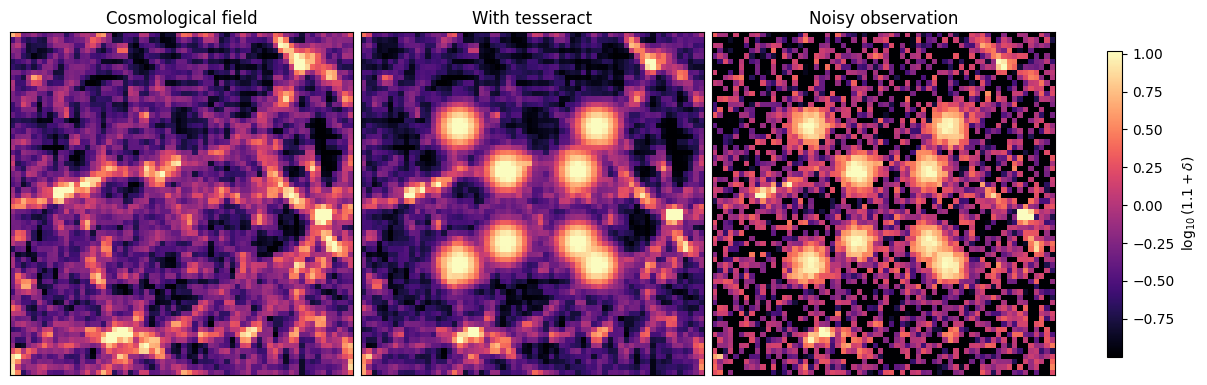

In [4]:
z = size // 2
slice_images = [
    log_density_for_plot(target_cosmological_base[:, :, z]),
    log_density_for_plot(target_clean[:, :, z]),
    log_density_for_plot(target_observation[:, :, z]),
]
vmin, vmax = np.percentile(np.concatenate([image.ravel() for image in slice_images]), [1.0, 99.0])

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for ax, image, title in zip(
    axes,
    slice_images,
    ["Cosmological field", "With tesseract", "Noisy observation"],
):
    im = ax.imshow(image.T, origin="lower", cmap="magma", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(im, ax=axes, shrink=0.8, label=r"$\log_{10}(1.1 + \delta)$")
plt.show()

## Step 2: Build and serve the Disco-DJ Tesseract

The Tesseract forward model receives Fourier-space white-noise modes in rFFT layout. Disco-DJ converts those modes into cosmological initial conditions using the Eisenstein & Hu power spectrum, determines initial positions and velocities using Lagrangian perturbation theory, evolves the particles with a particle-mesh N-body simulation, and returns the final density contrast. The entire pipeline is Jax-based and differentiable.

In [5]:
%%bash
tesseract build .

 [i] Building image ...
⠋ Processing
 [i] Built image sha256:ec5b03066470, ['discodj-ic-optimization:0.1.0', 'discodj-ic-optimization:latest']


["discodj-ic-optimization:0.1.0", "discodj-ic-optimization:latest"]


Start the Tesseract server. The notebook talks to this container through `tesseract-jax`, while the differentiable Disco-DJ forward model runs inside the container.


In [6]:
# NOTE: This requires a GPU container environment. In Linux, install via:
# sudo apt-get install -y nvidia-container-toolkit
# sudo nvidia-ctk runtime configure --runtime=docker
# sudo systemctl restart docker
discodj_tesseract = Tesseract.from_image(
    "discodj-ic-optimization",
    gpus=["0"],
)
discodj_tesseract.serve()

## Step 3: Forward sanity check

Before optimizing, we run the starting white-noise modes through the Tesseract and compare the result with the noisy target observation. The initial modes are a random field with a different seed than the target, so the initial forward result does not match the target (apart from the fact that there is no tesseract embedded in the initial conditions). The optimization will then iteratively modify the initial modes to match the target.

In [7]:
modes0 = jnp.asarray(initial_modes, dtype=jnp.float32)
k_grid_jax = jnp.asarray(k_grid, dtype=jnp.float32)
linear_power_grid_jax = jnp.asarray(linear_power_grid, dtype=jnp.float32)
rfft_factor_jax = jnp.asarray(rfft_factor, dtype=jnp.float32)
uv_filter_jax = jnp.asarray(uv_filter)
target_obs_jax = jnp.asarray(target_observation, dtype=jnp.float32)

MODEL_PARAMS = {
    "n_steps": 10,   # number of timesteps
    "boxsize": 100.0,  # boxsize in Mpc/h
    "a_ini": 0.02,  # initial scale factor (early time)
    "a_end": 1.0,  # final scale factor (late time, where target is defined)
    "lpt_order": 1,  # Lagrangian perturbation theory order for setting up initial particle positions and velocities
    "mass_assignment_order": 3,  # mass assignment order for particle-mesh-based force computation
}
display(MODEL_PARAMS)

def discodj_tesseract_fn(white_noise_fourier):
    return apply_tesseract(
        discodj_tesseract,
        inputs=dict(white_noise_fourier=white_noise_fourier, **MODEL_PARAMS),
    )

initial_outputs = discodj_tesseract_fn(modes0)
initial_final_density = initial_outputs["result"]

modes0.shape, initial_final_density.shape, initial_final_density.dtype

{'n_steps': 10,
 'boxsize': 100.0,
 'a_ini': 0.02,
 'a_end': 1.0,
 'lpt_order': 1,
 'mass_assignment_order': 3}

((64, 64, 33, 2), (64, 64, 64), dtype('float32'))

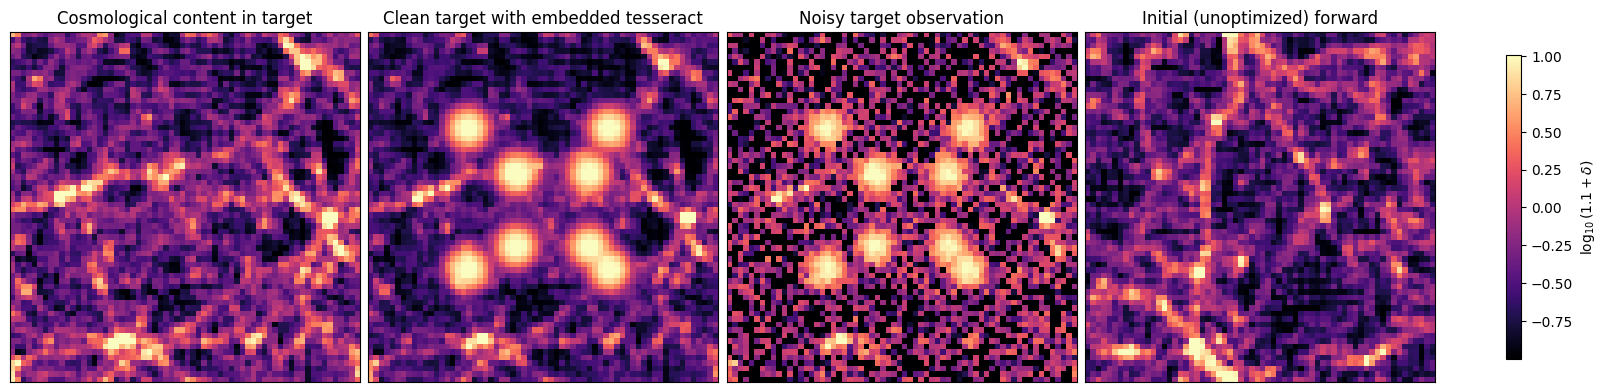

In [8]:
z = size // 2
preview_images = [
    log_density_for_plot(target_cosmological_base[:, :, z]),
    log_density_for_plot(target_clean[:, :, z]),
    log_density_for_plot(target_observation[:, :, z]),
    log_density_for_plot(np.asarray(initial_final_density[:, :, z])),
]
vmin, vmax = np.percentile(np.concatenate([image.ravel() for image in preview_images]), [1.0, 99.0])

fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
for ax, image, title in zip(
    axes,
    preview_images,
    ["Cosmological content in target", "Clean target with embedded tesseract", "Noisy target observation", "Initial (unoptimized) forward"],
):
    im = ax.imshow(image.T, origin="lower", cmap="magma", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(im, ax=axes, shrink=0.8, label=r"$\log_{10}(1.1 + \delta)$")
plt.show()

The cosmological content in the target (*left*) looks statistically similar to the initial forward result (*right*), but the spatial distribution of the structures (nodes, filaments) is different, as expected because the structures evolved from different white noise fields. Also, there is no tesseract in the initial forward result of course. The optimization will modify the initial modes to match the target, including the tesseract structure.

## Step 4: Negative log posterior

We now define the objective that will be optimized. In Bayesian language, we want to infer the initial Fourier-space white-noise field $w$ given the noisy late-time density observation $d$. Bayes' theorem gives

$$
p(w \mid d) =
\frac{p(d \mid w)\,p(w)}{p(d)} .
$$

In a realistic setting, one would want to sample this posterior distribution to capture the full range of initial conditions consistent with the observed target using a gradient-based MCMC method such as *Hamiltonian Monte Carlo*. For this demo, we will instead compute a **single maximum a posteriori (MAP) estimate** by maximizing $p(w \mid d)$ with respect to $w$.
For optimization, the evidence $p(d)$ is just a normalization constant, so maximizing the posterior is equivalent to minimizing the negative log posterior,

$$
-\log p(w \mid d)
=
-\log p(d \mid w)
-\log p(w)
+ \mathrm{const}.
$$

The likelihood compares the simulated late-time density field to the observed target. Given an initial white-noise field $w$, the differentiable Disco-DJ/Tesseract forward model produces the density contrast

$$
F(w) = \delta_\mathrm{final}(w).
$$

Assuming independent Gaussian observation noise with standard deviation $\sigma$, the negative log likelihood is

$$
-\log p(d \mid w)
=
\frac{1}{2\sigma^2}
\left\|
M_k \left[ F(w) - d \right]
\right\|_2^2
+ \mathrm{const}.,
$$
where we introduced the Fourier-space low-pass filter $M_k$ that restricts the comparison to large scales. Below, we will use a smooth low-pass filter that gradually admits more small-scale modes as the optimization progresses. In this way, the optimization will first drive large scales towards the target, with smaller scales (where gravitational collapse becomes more nonlinear) following later. This annealing strategy, which is common in cosmology, helps guide the optimizer towards good local minima by starting with a smoother, better-conditioned objective and gradually refining the solution as more modes are included.

The prior encodes the assumption that the initial conditions are statistically Gaussian. Since $w$ is a Fourier-space white-noise field, its modes are expected to be standard normal. This gives the Gaussian prior

$$
p(w) \propto
\exp\left(
-\frac{1}{2}
\left\| w \right\|_2^2
\right),
$$

or, equivalently,

$$
-\log p(w)
=
\frac{1}{2}
\left\| w \right\|_2^2
+ \mathrm{const}.
$$

Putting likelihood and prior together, the objective minimized in this notebook is

$$
-\log p(w \mid d) =
\frac{1}{2\sigma^2}
\left\|
M_k \left[ F(w) - d \right]
\right\|_2^2
+
\frac{1}{2}
\left\| w \right\|_2^2
+ \mathrm{const}.
$$

Here:

- $w$ is the active Fourier-space white-noise field being optimized,
- $F(w)$ is the differentiable Disco-DJ/Tesseract forward model,
- $d$ is the noisy late-time target density field,
- $M_k$ is the current smooth low-pass filter,
- $\sigma$ is the assumed observation noise level.

The data term encourages the evolved density field to match the observed target on the currently active scales. The prior term keeps unconstrained or weakly constrained modes close to typical Gaussian amplitudes, acting as a physically motivated regularizer.


The three optimization stages below use the same objective but **gradually increase the Fourier cutoff** of $M_k$ from large to small scales:

$$
k_\mathrm{cut}
=
\frac{k_\mathrm{Nyquist}}{4},
\qquad
\frac{k_\mathrm{Nyquist}}{2},
\qquad
k_\mathrm{Nyquist}.
$$

To improve optimization efficiency, we additionally introduce a simple diagonal **Fourier-space preconditioner** based on an approximate posterior precision from linear theory. This approximately equalizes the local curvature of different Fourier modes, reducing stiffness in the optimization problem and accelerating convergence.

The following cells collect utility functions needed to evaluate the negative log posterior.
The most important function is `objective`, which returns the negative log posterior together with useful diagnostic quantities.

In [9]:
# Helper function for making a 3D field with rFFT layout respect Hermitian symmetry
def enforce_hermitian_symmetry_rfft3(modes_complex):
    res = modes_complex.shape[0]
    half = res // 2
    corner = jnp.array([0, half])
    ii, jj, kk = jnp.meshgrid(corner, corner, corner, indexing="ij")
    modes_complex = modes_complex.at[ii.ravel(), jj.ravel(), kk.ravel()].set(
        jnp.real(modes_complex[ii.ravel(), jj.ravel(), kk.ravel()]).astype(jnp.complex64)
    )

    modes_complex = modes_complex.at[half + 1 :, 1:, 0].set(
        jnp.conj(jnp.fliplr(jnp.flipud(modes_complex[1:half, 1:, 0])))
    )
    modes_complex = modes_complex.at[half + 1 :, 0, 0].set(jnp.conj(modes_complex[half - 1 : 0 : -1, 0, 0]))
    modes_complex = modes_complex.at[0, half + 1 :, 0].set(jnp.conj(modes_complex[0, half - 1 : 0 : -1, 0]))
    modes_complex = modes_complex.at[half, half + 1 :, 0].set(jnp.conj(modes_complex[half, half - 1 : 0 : -1, 0]))

    modes_complex = modes_complex.at[half + 1 :, 1:, half].set(
        jnp.conj(jnp.fliplr(jnp.flipud(modes_complex[1:half, 1:, half])))
    )
    modes_complex = modes_complex.at[half + 1 :, 0, half].set(
        jnp.conj(modes_complex[half - 1 : 0 : -1, 0, half])
    )
    modes_complex = modes_complex.at[0, half + 1 :, half].set(
        jnp.conj(modes_complex[0, half - 1 : 0 : -1, half])
    )
    modes_complex = modes_complex.at[half, half + 1 :, half].set(
        jnp.conj(modes_complex[half, half - 1 : 0 : -1, half])
    )
    return modes_complex

In [10]:
modes_shape = initial_modes.shape[:-1]
uv_indices = np.where(uv_filter)
active_modes0_complex = (initial_modes[..., 0] + 1j * initial_modes[..., 1])[uv_filter]
active_modes = jnp.asarray(
    np.stack([active_modes0_complex.real, active_modes0_complex.imag], axis=-1),
    dtype=jnp.float32,
)

norm_fac = (size / float(MODEL_PARAMS["boxsize"])) ** 3
linear_delta_scale = jnp.sqrt(linear_power_grid_jax * norm_fac)
linear_delta_scale = jnp.where(k_grid_jax > 0.0, linear_delta_scale, 0.0)

def pack_active_modes(active_real_imag):
    """Expand active rFFT modes back into the full Hermitian-packed field."""
    complex_active = active_real_imag[:, 0] + 1j * active_real_imag[:, 1]
    modes_complex = jnp.zeros(modes_shape, dtype=jnp.complex64)
    modes_complex = modes_complex.at[uv_filter_jax].set(complex_active)
    modes_complex = enforce_hermitian_symmetry_rfft3(modes_complex)
    return jnp.stack([modes_complex.real, modes_complex.imag], axis=-1).astype(jnp.float32)

def linear_delta_from_modes(white_noise_fourier):
    """Convert Fourier white-noise modes into the corresponding linear density field (delta_lin(k) = sqrt(P(k)) * w(k))."""
    modes_complex = white_noise_fourier[..., 0] + 1j * white_noise_fourier[..., 1]
    modes_complex = enforce_hermitian_symmetry_rfft3(modes_complex)
    modes_complex = modes_complex / jnp.sqrt(2.0) * size ** 1.5
    delta_k = modes_complex * linear_delta_scale
    return jnp.fft.irfftn(delta_k, s=(size, size, size), axes=(0, 1, 2)).astype(jnp.float32)

def lowpass_taper_grid(k_cut, taper_start_fraction=0.85):
    """Build the smooth Fourier-space low-pass mask for one annealing cutoff."""
    k_start = taper_start_fraction * k_cut
    x = jnp.clip((k_grid_jax - k_start) / (k_cut - k_start), 0.0, 1.0)
    taper = 0.5 * (1.0 + jnp.cos(jnp.pi * x))
    return jnp.where(k_grid_jax < k_cut, taper, 0.0).astype(jnp.float32)

def filter_field(field, k_cut):
    """Apply the current smooth low-pass mask to a real-space field."""
    return jnp.fft.irfftn(
        jnp.fft.rfftn(field, axes=(0, 1, 2)) * lowpass_taper_grid(k_cut),
        s=field.shape,
        axes=(0, 1, 2),
    ).astype(jnp.float32)

def objective(active_real_imag, k_cut):
    """Evaluate the negative log posterior and auxiliary diagnostics."""
    white_noise_fourier = pack_active_modes(active_real_imag)
    final_delta = discodj_tesseract_fn(white_noise_fourier)["result"]
    residual = filter_field(final_delta - target_obs_jax, k_cut)
    data_loss = 0.5 * jnp.sum(jnp.square(residual)) / (noise_sigma ** 2)
    modes_complex = white_noise_fourier[..., 0] + 1j * white_noise_fourier[..., 1]
    modes_complex = enforce_hermitian_symmetry_rfft3(modes_complex)
    prior_loss = 0.5 * jnp.sum(jnp.square(jnp.abs(modes_complex)) * rfft_factor_jax)
    return data_loss + prior_loss, (data_loss, prior_loss, final_delta, white_noise_fourier)

def preconditioner(k_cut):
    """Compute diagonal Fourier-mode preconditioner weights for active modes."""
    # Approximate inverse posterior covariance for the active rFFT modes with linear theory.
    # The data precision follows the same smooth low-pass used by the residual.
    data_precision = linear_power_grid_jax / n2
    precond_grid = (data_precision * lowpass_taper_grid(k_cut) + 1.0) * rfft_factor_jax
    return precond_grid[uv_filter_jax]


def active_to_preconditioned(active_real_imag, k_cut):
    """Map active optimization variables into preconditioned coordinates."""
    scale = jnp.sqrt(preconditioner(k_cut))[:, None]
    return active_real_imag * scale


def preconditioned_to_active(preconditioned_real_imag, k_cut):
    """Map preconditioned optimization variables back to active mode coordinates."""
    scale = jnp.sqrt(preconditioner(k_cut))[:, None]
    return preconditioned_real_imag / scale


def objective_preconditioned(preconditioned_real_imag, k_cut):
    """Evaluate the objective after undoing the optimization preconditioner."""
    active_real_imag = preconditioned_to_active(preconditioned_real_imag, k_cut)
    return objective(active_real_imag, k_cut)


preconditioned_value_and_grad = jax.jit(
    jax.value_and_grad(objective_preconditioned, argnums=0, has_aux=True)
)

In [11]:
def evaluate_stage(active_real_imag, k_cut):
    """Evaluate one cutoff stage and collect fields and loss diagnostics."""
    value, aux = objective(active_real_imag, k_cut)
    data_loss, prior_loss, final_delta, white_noise_fourier = aux
    linear_delta = linear_delta_from_modes(white_noise_fourier)
    return {
        "active_modes": active_real_imag,
        "value": value,
        "data_loss": data_loss,
        "prior_loss": prior_loss,
        "final_delta": final_delta,
        "linear_delta": linear_delta,
        "white_noise_fourier": white_noise_fourier,
    }


def run_stage(active_start, k_cut, maxiter):
    """Optimize active modes for one annealing cutoff with SciPy L-BFGS-B."""
    latest = {"total": None, "data": None, "prior": None}
    history = []
    y = active_to_preconditioned(jnp.asarray(active_start, dtype=jnp.float32), k_cut)

    def scipy_value_and_grad(y_flat):
        """Return scalar objective and flattened gradient for SciPy."""
        y_scipy = jnp.asarray(y_flat.reshape(active_start.shape), dtype=jnp.float32)
        (value, aux), grad = preconditioned_value_and_grad(y_scipy, k_cut)
        data_loss, prior_loss, _, _ = aux
        latest["total"] = float(value)
        latest["data"] = float(data_loss)
        latest["prior"] = float(prior_loss)
        return float(value), np.asarray(grad, dtype=np.float64).ravel()

    with tqdm(total=maxiter) as pbar:
        def callback(intermediate_result):
            """Record progress and update the progress bar after each iteration."""
            history.append([latest["total"], latest["data"], latest["prior"]])
            pbar.set_postfix(
                total=f"{latest['total']:.4e}",
                data=f"{latest['data']:.4e}",
                prior=f"{latest['prior']:.4e}",
            )
            pbar.update(1)

        opt = minimize(
            scipy_value_and_grad,
            np.asarray(y, dtype=np.float64).ravel(),
            method="L-BFGS-B",
            jac=True,
            callback=callback,
            options={"maxiter": maxiter, "maxls": 40},
        )

    y = jnp.asarray(opt.x.reshape(active_start.shape), dtype=jnp.float32)

    active = preconditioned_to_active(y, k_cut)
    result = evaluate_stage(active, k_cut)
    result["history"] = np.asarray(history, dtype=np.float32)
    result["opt_result"] = {
        "method": "scipy.L-BFGS-B",
        "success": opt.success,
        "message": opt.message,
        "nit": opt.nit,
        "nfev": opt.nfev,
        "njev": opt.njev,
        "maxiter": maxiter,
    }
    print(
        f"SciPy L-BFGS-B finished: success={opt.success}, "
        f"nit={opt.nit}, nfev={opt.nfev}, njev={opt.njev}"
    )
    print(
        f"Final stage loss: total={float(result['value']):.6e}, "
        f"data={float(result['data_loss']):.6e}, "
        f"prior={float(result['prior_loss']):.6e}"
    )
    return result


def inspect_stage(stage_result, title, k_cut=None):
    """Plot stage diagnostics and print full-field summary metrics."""
    linear_slice = np.asarray(stage_result["linear_delta"][:, :, z])
    final = np.asarray(stage_result["final_delta"])
    target = target_observation
    if k_cut is not None:
        final = np.asarray(filter_field(jnp.asarray(final), k_cut))
        target = np.asarray(filter_field(target_obs_jax, k_cut))
    final_plot = log_density_for_plot(final[:, :, z])
    target_plot = log_density_for_plot(target[:, :, z])
    density_vmin, density_vmax = np.percentile(
        np.concatenate([final_plot.ravel(), target_plot.ravel()]),
        [1.0, 99.0],
    )
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
    panels = [
        (linear_slice, "Optimized linear field", "viridis", None),
        (final_plot, "Optimized final", "magma", (density_vmin, density_vmax)),
        (target_plot, "Target observation", "magma", (density_vmin, density_vmax)),
    ]
    for ax, (image, panel_title, cmap, limits) in zip(axes, panels):
        kwargs = {} if limits is None else dict(vmin=limits[0], vmax=limits[1])
        im = ax.imshow(image.T, origin="lower", cmap=cmap, **kwargs)
        ax.set_title(panel_title)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, shrink=0.8)
    fig.suptitle(title)
    plt.show()
    final_full = np.asarray(stage_result["final_delta"])
    corr = float(np.corrcoef(final_full.ravel(), target_observation.ravel())[0, 1])
    mse = float(np.mean((final_full - target_observation) ** 2))
    print(
        f"{title}: total={float(stage_result['value']):.6e}, "
        f"data={float(stage_result['data_loss']):.6e}, "
        f"prior={float(stage_result['prior_loss']):.6e}, "
        f"full_mse={mse:.6e}, full_corr={corr:.6e}"
    )

In [12]:
OPTIMIZATION_RESULTS = OUTPUTS / "optimization_results.npz"
LOAD_OPTIMIZATION_RESULTS = False

_STAGE_FIELDS = (
    "active_modes",
    "white_noise_fourier",
    "linear_delta",
    "final_delta",
    "value",
    "data_loss",
    "prior_loss",
    "history",
)


def _stage_arrays(stage_result, prefix):
    """Convert one stage result dictionary into flat arrays for NPZ storage."""
    return {
        f"{prefix}_{field}": np.asarray(stage_result[field], dtype=np.float32)
        for field in _STAGE_FIELDS
    }


def save_optimization_results(path, stage1, stage2, stage3):
    """Store all optimization stages needed to continue the notebook without rerunning L-BFGS."""
    arrays = {}
    for prefix, stage in (
        ("stage1", stage1),
        ("stage2", stage2),
        ("stage3", stage3),
    ):
        arrays.update(_stage_arrays(stage, prefix))
    np.savez_compressed(path, **arrays)


def _load_stage(data, prefix):
    """Load one optimization stage dictionary from an NPZ file."""
    return {
        "active_modes": jnp.asarray(data[f"{prefix}_active_modes"], dtype=jnp.float32),
        "white_noise_fourier": jnp.asarray(data[f"{prefix}_white_noise_fourier"], dtype=jnp.float32),
        "linear_delta": jnp.asarray(data[f"{prefix}_linear_delta"], dtype=jnp.float32),
        "final_delta": jnp.asarray(data[f"{prefix}_final_delta"], dtype=jnp.float32),
        "value": jnp.asarray(data[f"{prefix}_value"], dtype=jnp.float32),
        "data_loss": jnp.asarray(data[f"{prefix}_data_loss"], dtype=jnp.float32),
        "prior_loss": jnp.asarray(data[f"{prefix}_prior_loss"], dtype=jnp.float32),
        "history": np.asarray(data[f"{prefix}_history"], dtype=np.float32),
        "opt_result": {"method": "loaded from optimization_results.npz"},
    }


def load_optimization_results(path):
    """Load the three cached optimization stages from disk."""
    with np.load(path) as data:
        return tuple(_load_stage(data, prefix) for prefix in ("stage1", "stage2", "stage3"))


if LOAD_OPTIMIZATION_RESULTS:
    stage1, stage2, stage3 = load_optimization_results(OPTIMIZATION_RESULTS)
    print(f"Loaded optimization results from {OPTIMIZATION_RESULTS}")

Loaded optimization results from [...]/outputs/optimization_results.npz


### Stage 1: large scales (`k_cut = k_Nyquist / 4`)

The first stage fits only the largest structures. This gives the optimizer a smooth, well-conditioned target before smaller-scale modes are allowed to participate.


In [13]:
if not LOAD_OPTIMIZATION_RESULTS:
    stage1 = run_stage(active_modes, k_nyquist / 4.0, maxiter=250)

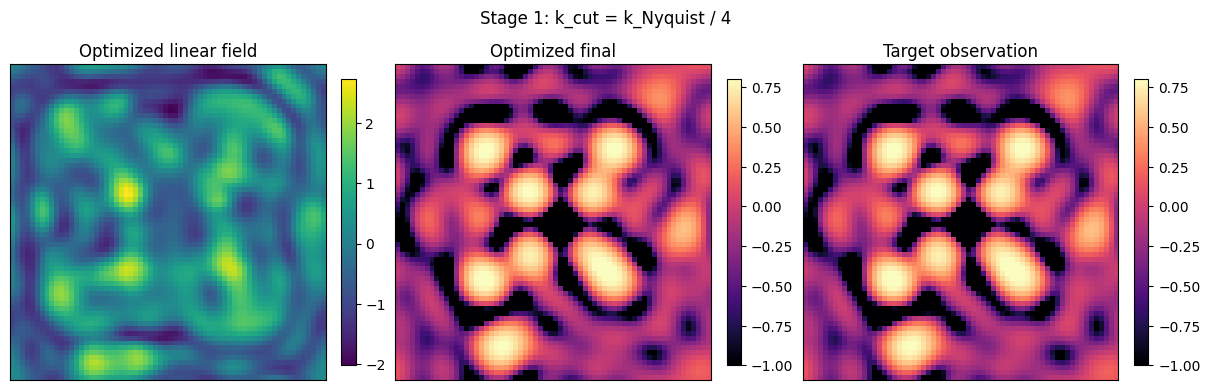

Stage 1: k_cut = k_Nyquist / 4: total=1.126058e+03, data=1.276510e+02, prior=9.984066e+02, full_mse=5.692020e+00, full_corr=5.662396e-01


In [14]:
inspect_stage(stage1, "Stage 1: k_cut = k_Nyquist / 4", k_nyquist / 4.0)

### Stage 2: intermediate scales (`k_cut = k_Nyquist / 2`)

The second stage starts from the large-scale solution and admits more Fourier modes, refining the cosmic web and the visible target structure.


In [15]:
if not LOAD_OPTIMIZATION_RESULTS:
    stage2 = run_stage(stage1["active_modes"], k_nyquist / 2.0, maxiter=500)

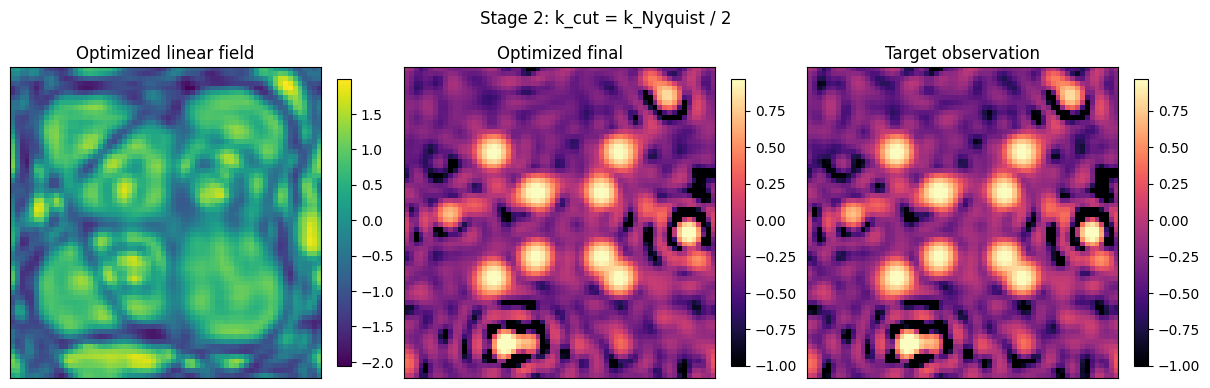

Stage 2: k_cut = k_Nyquist / 2: total=3.065471e+03, data=7.761663e+02, prior=2.289305e+03, full_mse=1.061856e+00, full_corr=8.868427e-01


In [16]:
inspect_stage(stage2, "Stage 2: k_cut = k_Nyquist / 2", k_nyquist / 2.0)

### Stage 3: full retained Fourier range (`k_cut = k_Nyquist`)

The final stage optimizes all retained modes. This is the result used for the final 2D and 3D comparisons.


In [17]:
if not LOAD_OPTIMIZATION_RESULTS:
    stage3 = run_stage(stage2["active_modes"], k_nyquist, maxiter=1000)

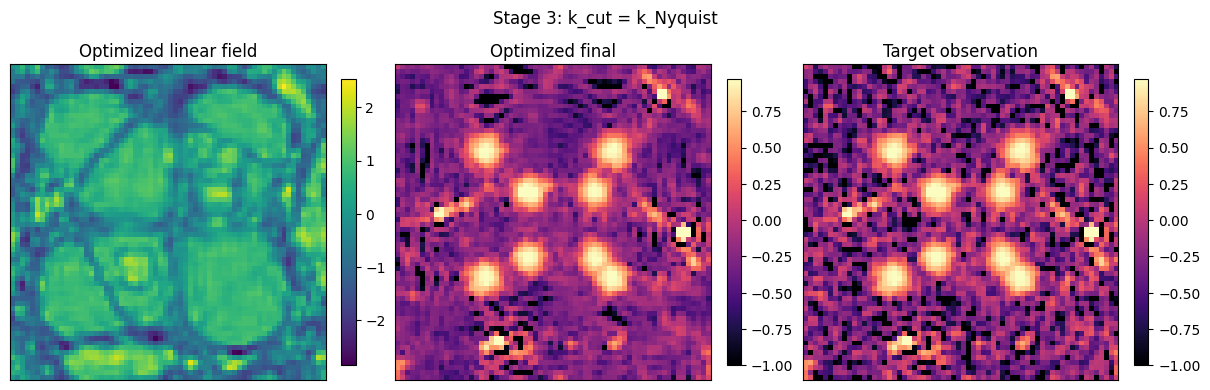

Stage 3: k_cut = k_Nyquist: total=1.760819e+04, data=1.168949e+04, prior=5.918703e+03, full_mse=3.412659e-01, full_corr=9.622640e-01


In [18]:
inspect_stage(stage3, "Stage 3: k_cut = k_Nyquist", k_nyquist)

### Visual interpretation of the annealing stages

The early stages should be judged mainly by whether the large-scale web and the embedded tesseract are in the right places. By $k_\mathrm{cut} = k_\mathrm{Nyquist} / 2$, the optimized final field is expected to look very similar to the target on coherent structures.

At the full retained cutoff $k_\mathrm{cut} = k_\mathrm{Nyquist}$, visible pixel-scale differences are not necessarily a failure: the target observation includes random noise, while the forward model can only produce density fields reachable by gravitational evolution from plausible initial conditions. The posterior therefore compromises between matching the data and respecting the white-noise prior on $w$, so the optimized final field should usually look cleaner than the noisy target rather than chasing every noisy pixel.

## Step 5: Save and inspect the final result

Save the annealed reconstruction and inspect the optimization history. The final 3D comparison shows the late-time cosmological base field before tesseract embedding, the clean late-time tesseract target, the optimized linear field, and the optimized late-time field.


In [19]:
save_optimization_results(OPTIMIZATION_RESULTS, stage1, stage2, stage3)

print(f"saved optimization results to {OPTIMIZATION_RESULTS}")
print(f"target observation STD: {float(np.std(target_observation)):.6e}")
print(f"initial final-density STD: {float(np.std(np.asarray(initial_final_density))):.6e}")
print(f"optimized final-density STD: {float(np.std(np.asarray(stage3['final_delta']))):.6e}")


saved optimization results to [...]/outputs/optimization_results.npz
target observation STD: 2.146356e+00
initial final-density STD: 3.478884e+00
optimized final-density STD: 2.053593e+00


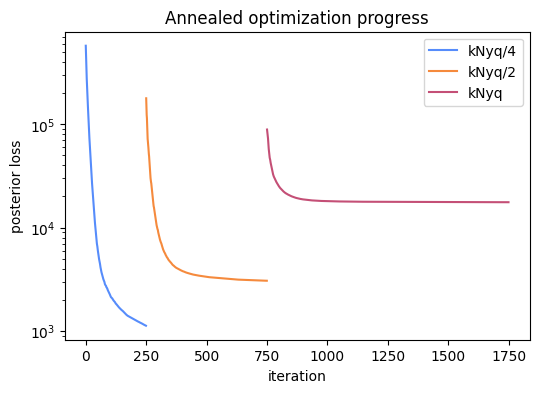

In [20]:
histories = [stage1["history"], stage2["history"], stage3["history"]]
labels = ["kNyq/4", "kNyq/2", "kNyq"]
plt.figure(figsize=(6, 4))
offset = 0
for history, label in zip(histories, labels):
    xs = np.arange(offset, offset + len(history))
    plt.plot(xs, history[:, 0], label=label)
    offset += len(history)
plt.xlabel("iteration")
plt.ylabel("posterior loss")
plt.yscale("log")
plt.legend()
plt.title("Annealed optimization progress")
plt.show()

In [21]:
# 3D comparison at the final annealing stage, k_cut = k_Nyquist.
def plotly_volume_panel(fig, field, *, row, col, title, mode, stride=2):
    field = np.asarray(field, dtype=np.float32)
    if mode == "density":
        values = log_density_for_plot(field)
        colorscale = "Magma"
        isomin, isomax = np.percentile(values, [70.0, 99.5])
        colorbar_title = "log density"
    elif mode == "linear":
        values = field
        positive = values[values > 0.0]
        if positive.size == 0:
            isomin, isomax = np.percentile(values, [70.0, 99.5])
        else:
            isomin, isomax = np.percentile(positive, [55.0, 99.5])
        colorscale = "Viridis"
        colorbar_title = "linear delta"
    else:
        raise ValueError(f"unknown mode: {mode}")

    values = values[::stride, ::stride, ::stride]
    xx, yy, zz = np.mgrid[:values.shape[0], :values.shape[1], :values.shape[2]]
    fig.add_trace(
        go.Volume(
            x=xx.ravel(),
            y=yy.ravel(),
            z=zz.ravel(),
            value=values.ravel(),
            isomin=float(isomin),
            isomax=float(isomax),
            opacity=0.08,
            surface_count=12,
            colorscale=colorscale,
            caps=dict(x_show=False, y_show=False, z_show=False),
            showscale=True,
            colorbar=dict(title=colorbar_title, len=0.38),
            name=title,
        ),
        row=row,
        col=col,
    )


cosmological_base_for_plot = np.asarray(filter_field(jnp.asarray(target_cosmological_base), k_nyquist))
clean_target_for_plot = np.asarray(filter_field(jnp.asarray(target_clean), k_nyquist))
optimized_linear_for_plot = np.asarray(stage3["linear_delta"])
optimized_final_for_plot = np.asarray(filter_field(jnp.asarray(stage3["final_delta"]), k_nyquist))

fig = make_subplots(
    rows=2,
    cols=2,
    specs=[[{"type": "scene"}, {"type": "scene"}], [{"type": "scene"}, {"type": "scene"}]],
    subplot_titles=(
        "Cosmological base field",
        "Clean target with tesseract",
        "Optimized linear field",
        "Optimized final field",
    ),
    horizontal_spacing=0.02,
    vertical_spacing=0.06,
)

plotly_volume_panel(fig, cosmological_base_for_plot, row=1, col=1, title="Cosmological base field", mode="density")
plotly_volume_panel(fig, clean_target_for_plot, row=1, col=2, title="Clean target with tesseract", mode="density")
plotly_volume_panel(fig, optimized_linear_for_plot, row=2, col=1, title="Optimized linear field", mode="linear")
plotly_volume_panel(fig, optimized_final_for_plot, row=2, col=2, title="Optimized final field", mode="density")

scene_style = dict(
    aspectmode="cube",
    xaxis=dict(visible=False),
    yaxis=dict(visible=False),
    zaxis=dict(visible=False),
)
fig.update_layout(
    title="Final reconstruction: context, target, and optimized fields",
    width=1150,
    height=1050,
    margin=dict(l=0, r=0, t=80, b=0),
    scene=scene_style,
    scene2=scene_style,
    scene3=scene_style,
    scene4=scene_style,
)
fig.show()

### 3D forward-evolution animations

The next two cells visualize the N-body forward evolution as 3D volume GIFs: first for the original initial conditions before optimization, then for the optimized initial conditions.


In [22]:
def run_forward_trajectory(white_noise_fourier, max_animation_frames=12):
    """Run the Tesseract forward model and return selected density trajectory frames."""
    trajectory_outputs = apply_tesseract(
        discodj_tesseract,
        inputs=dict(
            white_noise_fourier=white_noise_fourier,
            **MODEL_PARAMS,
            return_trajectory=True,
            trajectory_max_frames=max_animation_frames,
        ),
    )
    trajectory = np.asarray(trajectory_outputs["trajectory"], dtype=np.float32)
    trajectory_a = np.asarray(trajectory_outputs["trajectory_a"], dtype=np.float32)
    del trajectory_outputs
    gc.collect()
    return trajectory, trajectory_a


def select_animation_frames(trajectory, trajectory_a, max_animation_frames=12):
    """Select an evenly spaced subset of trajectory frames for GIF rendering."""
    if trajectory.shape[0] > max_animation_frames:
        frame_indices = np.linspace(0, trajectory.shape[0] - 1, max_animation_frames, dtype=int)
    else:
        frame_indices = np.arange(trajectory.shape[0], dtype=int)
    return frame_indices, trajectory_a[frame_indices]


def trajectory_color_limits(trajectory, frame_indices, volume_stride=2):
    """Compute fixed log-density color limits across the selected animation frames."""
    first_values = log_density_for_plot(trajectory[frame_indices[0]])[
        ::volume_stride,
        ::volume_stride,
        ::volume_stride,
    ].astype(np.float32, copy=False)
    frame_shape = first_values.shape
    percentile_values = np.empty((len(frame_indices), first_values.size), dtype=np.float32)
    percentile_values[0] = first_values.ravel()
    for row, frame_index in enumerate(frame_indices[1:], start=1):
        percentile_values[row] = log_density_for_plot(trajectory[frame_index])[
            ::volume_stride,
            ::volume_stride,
            ::volume_stride,
        ].ravel()
    vmin, vmax = np.percentile(percentile_values, [70.0, 99.7])
    del first_values, percentile_values
    gc.collect()
    return float(vmin), float(vmax), frame_shape


def volume_coordinates(frame_shape):
    """Build flattened voxel coordinates for one Plotly volume frame shape."""
    xx, yy, zz = np.mgrid[:frame_shape[0], :frame_shape[1], :frame_shape[2]]
    x_flat = xx.ravel()
    y_flat = yy.ravel()
    z_flat = zz.ravel()
    del xx, yy, zz
    return x_flat, y_flat, z_flat


def forward_volume_figure(
    values,
    a_value,
    *,
    title_prefix,
    x_flat,
    y_flat,
    z_flat,
    vmin,
    vmax,
    width=850,
    height=750,
    surface_count=12,
):
    """Render one forward-evolution frame as a fixed-scale Plotly volume."""
    camera = dict(eye=dict(x=1.45, y=1.45, z=1.0), up=dict(x=0.0, y=0.0, z=1.0))
    fig = go.Figure(
        data=go.Volume(
            x=x_flat,
            y=y_flat,
            z=z_flat,
            value=values.ravel(),
            isomin=float(vmin),
            isomax=float(vmax),
            cmin=float(vmin),
            cmax=float(vmax),
            cauto=False,
            opacity=0.08,
            surface_count=surface_count,
            colorscale="Magma",
            caps=dict(x_show=False, y_show=False, z_show=False),
            colorbar=dict(
                title="log density",
                len=0.55,
                tickvals=np.linspace(float(vmin), float(vmax), 5),
            ),
        )
    )
    fig.update_layout(
        title=f"{title_prefix}: a = {float(a_value):.3f}",
        width=width,
        height=height,
        margin=dict(l=0, r=0, t=60, b=0),
        scene=dict(
            aspectmode="cube",
            camera=camera,
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            zaxis=dict(visible=False),
        ),
    )
    return fig


def build_global_gif_palette(paths, sample_scale=1):
    """Build one shared 256-color GIF palette from representative pixels across all frames."""
    samples = []
    for path in paths:
        with PILImage.open(path) as image:
            rgb = image.convert("RGB")
            sample_size = (
                max(1, rgb.width // sample_scale),
                max(1, rgb.height // sample_scale),
            )
            samples.append(rgb.resize(sample_size, PILImage.Resampling.BILINEAR))
            rgb.close()

    palette_width = max(sample.width for sample in samples)
    palette_height = sum(sample.height for sample in samples)
    palette_source = PILImage.new("RGB", (palette_width, palette_height))
    y_offset = 0
    for sample in samples:
        palette_source.paste(sample, (0, y_offset))
        y_offset += sample.height
        sample.close()

    palette_image = palette_source.quantize(
        colors=256,
        method=PILImage.Quantize.MEDIANCUT,
        dither=PILImage.Dither.NONE,
    )
    palette_source.close()
    return palette_image


def quantized_gif_frame(path, palette_image):
    """Convert one rendered PNG frame to the shared GIF palette."""
    with PILImage.open(path) as image:
        rgb = image.convert("RGB")
        frame = rgb.quantize(palette=palette_image, dither=PILImage.Dither.NONE)
        rgb.close()
        return frame


def iter_quantized_gif_frames(paths, palette_image):
    """Open and quantize rendered frame files lazily while Pillow writes the GIF."""
    for path in paths:
        frame = quantized_gif_frame(path, palette_image)
        try:
            yield frame
        finally:
            frame.close()


def render_volume_gif(
    trajectory,
    trajectory_a,
    gif_path,
    *,
    title_prefix,
    max_animation_frames=12,
    volume_stride=2,
    width=850,
    height=750,
    surface_count=12,
):
    """Render a memory-bounded 3D Plotly volume GIF from a density trajectory."""
    frame_indices, selected_a = select_animation_frames(
        trajectory,
        trajectory_a,
        max_animation_frames=max_animation_frames,
    )
    vmin, vmax, frame_shape = trajectory_color_limits(
        trajectory,
        frame_indices,
        volume_stride=volume_stride,
    )
    x_flat, y_flat, z_flat = volume_coordinates(frame_shape)

    with tempfile.TemporaryDirectory() as tmpdir:
        tmpdir = Path(tmpdir)
        frame_paths = []
        for frame_number, (frame_index, a_value) in enumerate(
            tqdm(zip(frame_indices, selected_a), total=len(frame_indices), desc=f"Rendering {title_prefix}")
        ):
            values = log_density_for_plot(trajectory[frame_index])[
                ::volume_stride,
                ::volume_stride,
                ::volume_stride,
            ].astype(np.float32, copy=False)
            fig = forward_volume_figure(
                values,
                a_value,
                title_prefix=title_prefix,
                x_flat=x_flat,
                y_flat=y_flat,
                z_flat=z_flat,
                vmin=vmin,
                vmax=vmax,
                width=width,
                height=height,
                surface_count=surface_count,
            )
            png_path = tmpdir / f"{gif_path.stem}_{frame_number:03d}.png"
            fig.write_image(str(png_path), format="png", width=width, height=height, scale=1)
            frame_paths.append(png_path)
            del fig, values
            gc.collect()

        gif_frame_paths = frame_paths + [frame_paths[-1]] * 4
        palette_image = build_global_gif_palette(frame_paths)
        first_frame = quantized_gif_frame(gif_frame_paths[0], palette_image)
        first_frame.save(
            gif_path,
            save_all=True,
            append_images=iter_quantized_gif_frames(gif_frame_paths[1:], palette_image),
            palette=palette_image.getpalette(),
            duration=160,
            loop=0,
            disposal=2,
            optimize=False,
        )
        first_frame.close()
        palette_image.close()

    del frame_indices, selected_a, x_flat, y_flat, z_flat
    gc.collect()
    return Image(filename=str(gif_path), embed=True)


def render_forward_evolution_gif(
    white_noise_fourier,
    gif_path,
    *,
    title_prefix,
    max_animation_frames=12,
    volume_stride=1,
):
    """Run a forward trajectory and render it as an embedded 3D GIF."""
    trajectory, trajectory_a = run_forward_trajectory(
        white_noise_fourier,
        max_animation_frames=max_animation_frames,
    )
    animation = render_volume_gif(
        trajectory,
        trajectory_a,
        gif_path,
        title_prefix=title_prefix,
        max_animation_frames=max_animation_frames,
        volume_stride=volume_stride,
    )
    del trajectory, trajectory_a
    gc.collect()
    return animation


#### Initial IC forward evolution

This animation starts from the **original initial modes** loaded from the target bundle. It shows the cosmological field evolved forward from the initial random noise before the optimizer has introduced the tesseract structure.

Rendering Initial forward evolution: 100%|██████████| 11/11 [02:23<00:00, 13.07s/it]


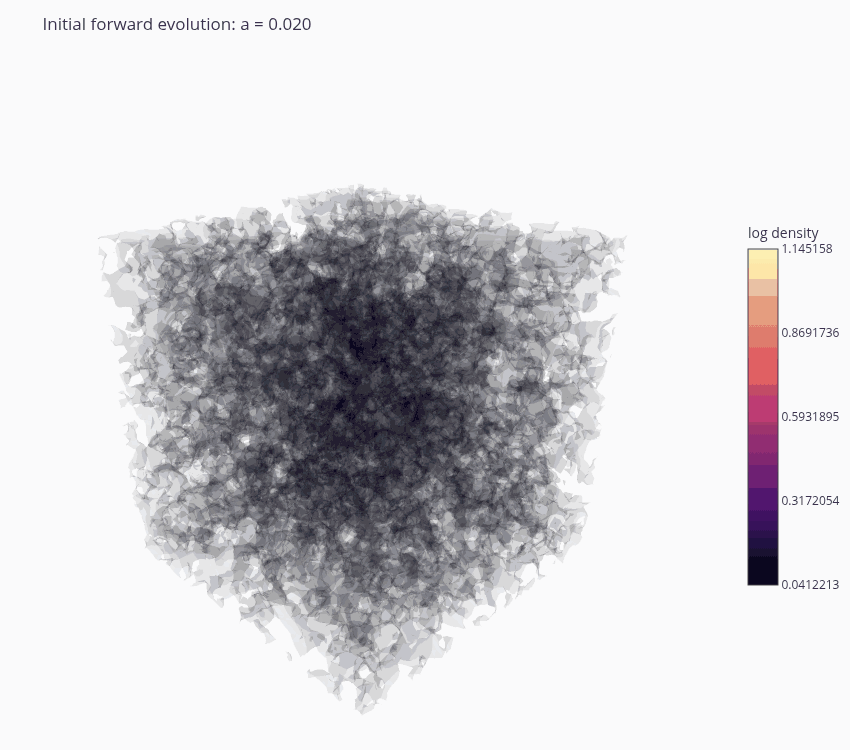

In [23]:
render_forward_evolution_gif(
    modes0,
    OUTPUTS / "initial_forward_evolution_3d.gif",
    title_prefix="Initial forward evolution"
)


#### Optimized IC forward evolution

This animation starts from the **optimized** initial modes from the final annealing stage.


Rendering Optimized forward evolution: 100%|██████████| 11/11 [01:42<00:00,  9.28s/it]


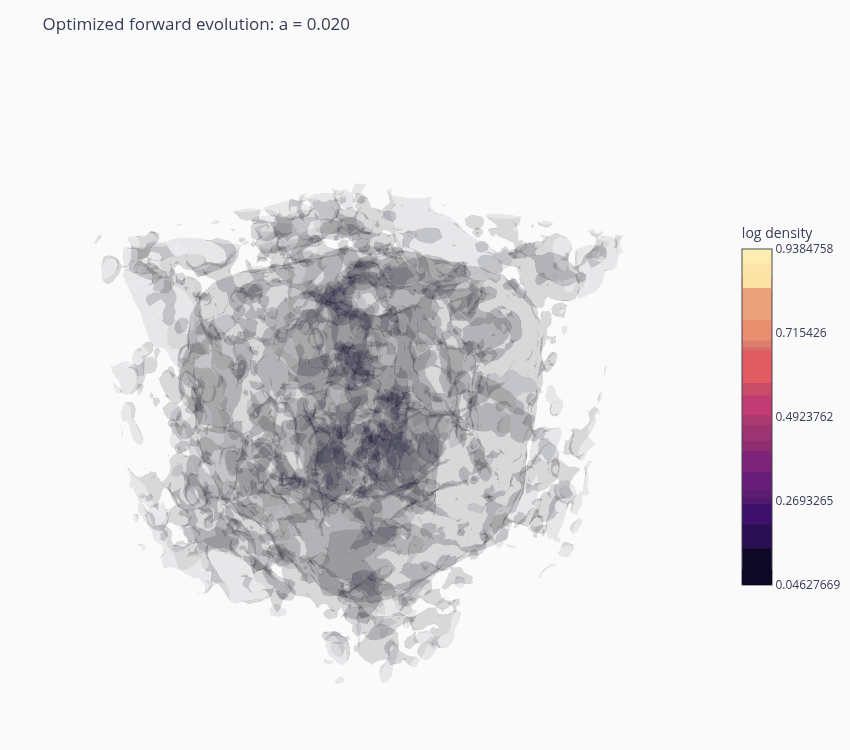

In [24]:
render_forward_evolution_gif(
    stage3["white_noise_fourier"],
    OUTPUTS / "optimized_forward_evolution_3d.gif",
    title_prefix="Optimized forward evolution",
)


In [25]:
# Tear down the Tesseract server when you are done.
discodj_tesseract.teardown()

## Takeaways
In this demo, we reconstructed the initial conditions of a cosmological structure formation simulation from a noisy late-time density field using differentiable simulation and gradient-based optimization.

- **End-to-end differentiable cosmological simulation.**
  By wrapping Disco-DJ inside a Tesseract, we obtained a self-contained differentiable forward model for cosmological structure formation. Gradients propagate automatically through the full pipeline, from the late-time density field back to the initial Fourier-space modes.

- **Field-level Bayesian inference.**
  Instead of fitting summary statistics such as power spectra, the optimization operates directly on the full 3D late-time density field. The objective combines a Gaussian likelihood with a physically motivated Gaussian prior on the initial white-noise modes.

- **High-dimensional optimization becomes practical.**
  The reconstruction problem involves thousands to millions of coupled parameters corresponding to Fourier modes of the initial conditions. Gradient-based optimization together with Fourier-space preconditioning makes this tractable even for large simulations.

- **Multi-scale optimization stabilizes the reconstruction.**
  The optimization proceeds from large to small scales using progressively less restrictive Fourier-space low-pass filters. This annealing strategy first reconstructs the broad large-scale structure before fitting increasingly nonlinear small-scale details.

- **Composable differentiable physics workflows.**
  The same Tesseract could be reused for full posterior sampling with Hamiltonian Monte Carlo. Also, the pipeline could be extended to include additional physical processes (e.g. galaxy formation) or observational effects (such as survey masks, instrument effects, etc.) by building new Tesseracts and incorporating them into the forward model.